# 🔢 Módulo 07: Sistemas, Inferencia Eficiente y Cuantización
## Capítulo 2: Cuantización de Modelos From Scratch: De FP32 a INT8 e INT4, Calibración Simétrica/Asimétrica y AWQ

> *"Un modelo de 70.000 millones de parámetros en coma flotante estándar de 32 bits (FP32) ocupa 280 GB de memoria: imposible de ejecutar en casi cualquier máquina del mundo. Pero el cerebro humano no opera con 32 bits de precisión aritmética en cada sinapsis. La cuantización es el arte de mapear el continuum de los números reales a una cuadrícula discreta de enteros pequeños (INT8, INT4 e incluso INT2). En este capítulo aprenderás la matemática exacta de la escala ($s$) y el punto cero ($z$), desentrañarás el misterio de los 'outliers' numéricos que colapsaban la cuantización clásica y construirás algoritmos de cuantización simétrica, asimétrica y AWQ desde cero."*

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mcarbonell/algo-to-ai/blob/main/notebooks/07_systems_and_efficiency/02_quantization_from_scratch.ipynb)

---

### ⚙️ Inicialización del Entorno
Cargamos las librerías matemáticas y fijamos semillas para asegurar reproducibilidad determinista.

In [1]:
# !pip install -q numpy matplotlib torch
from typing import Tuple, List, Dict, Optional
import numpy as np
import matplotlib.pyplot as plt
import torch

np.random.seed(42)
torch.manual_seed(42)
print("✅ Entorno listo para estudiar Cuantización INT8/INT4 y AWQ from scratch")

✅ Entorno listo para estudiar Cuantización INT8/INT4 y AWQ from scratch


---

## 1. 📜 Contexto Histórico y Proceso de Descubrimiento

### La Anatomía de los Tipos Numéricos en Deep Learning
Durante décadas, las redes se entrenaron e infirieron en **FP32** (Single Precision, estándar IEEE 754):
* **FP32 (4 bytes):** 1 bit de signo, 8 bits de exponente, 23 bits de mantisa (precisión de $\approx 7$ decimales).
* **FP16 / BF16 (2 bytes):** Mitiga el consumo a la mitad. BF16 (Google Brain) preservó los 8 bits de exponente de FP32 para evitar el desbordamiento (*underflow/overflow*).
* **INT8 (1 byte):** 256 niveles enteros discretos ($[-128, 127]$). Reduce la memoria en un $75\%$ respecto a FP32.
* **INT4 (0.5 bytes / nibble):** Solo 16 niveles enteros discretos ($[-8, 7]$ o $[0, 15]$). Permite comprimir un modelo de 70B parámetros a menos de 38 GB de memoria.

### El Misterio de los Outliers Emergentes (Tim Dettmers et al., NeurIPS 2022)
Durante mucho tiempo, cuantizar modelos de visión o pequeños transformers a INT8 era rutinario.
Sin embargo, cuando la industria intentó cuantizar LLMs mayores a **6.7B parámetros**, ocurrió un fenómeno desconcertante: **la perplejidad del modelo colapsaba y el LLM balbuceaba incoherencias**.

Tim Dettmers (Universidad de Washington) descubrió la causa en su célebre paper **`LLM.int8()`**:
* A partir de 6.7B parámetros, emerge en los LLMs un fenómeno espontáneo: en el $0.1\%$ de las dimensiones de activación, los valores alcanzan magnitudes gigantescas (hasta 100 veces mayores que el promedio normal).
* Al cuantizar un vector que contiene un outlier de valor 100 junto a valores habituales de 0.1, **la escala $s$ se estira tanto que todos los valores normales colapsan a 0**, destruyendo la señal semántica del modelo.

### La Solución Moderna: GPTQ (2022) y AWQ (MIT Han Lab, 2023)
Para cuantizar a INT4 sin perder inteligencia:
1. **GPTQ (Frantar et al., 2022):** Aplica la teoría de segundo orden de la matriz Hessiana para compensar analíticamente el error de cuantización en los pesos adyacentes.
2. **AWQ (Activation-aware Weight Quantization - Ji Lin et al., 2023):** Descubrió que **no todos los pesos son igualmente importantes**. Aquellos pesos que multiplican a las dimensiones de activación que contienen outliers son críticos. Protegiendo ese $1\%$ de pesos destacados mediante un re-escalado por canales, se logra cuantizar el $99\%$ restante a INT4 sin apenas pérdida de precisión.

---

## 2. 🧠 Intuición Geométrica y Mecánica (Mentalidad de Algoritmista)

### La Ecuación de Mapeo Afín (Quantization & Dequantization)
El objetivo es mapear un número real continuo $x \in [x_{min}, x_{max}]$ a un entero discreto $q \in [q_{min}, q_{max}]$:
$$\mathbf{x \approx s \cdot (q - z)}$$

Donde:
* $s \in \mathbb{R}^+$ es el factor de **Escala (*Scale*)**.
* $z \in \mathbb{Z}$ es el **Punto Cero (*Zero-Point*)**, que garantiza que el valor real $0.0$ se represente exactamente como un entero sin error de redondeo (crucial para padding y activaciones con ceros como ReLU).

### 1. Cuantización Asimétrica (*Asymmetric / Min-Max Quantization*):
Aprovecha todo el rango dinámico asimétrico de los datos:
$$s = \frac{x_{max} - x_{min}}{q_{max} - q_{min}}$$
$$z = \text{round}\left( -\frac{x_{min}}{s} \right) + q_{min}$$
$$q = \text{clip}\left( \text{round}\left( \frac{x}{s} \right) + z, \; q_{min}, \; q_{max} \right)$$

### 2. Cuantización Simétrica (*Symmetric Quantization*):
Fuerza a que el punto cero sea estrictamente cero ($z = 0$) centrando el rango en $\alpha = \max(|x_{min}|, |x_{max}|)$:
$$s = \frac{\max(|x|)}{q_{max}}$$
$$q = \text{clip}\left( \text{round}\left( \frac{x}{s} \right), \; -q_{max}, \; q_{max} \right)$$

* **¿Por qué la industria prefiere Cuantización Simétrica?**
  Al multiplicar matrices enteras $Y = X_q \cdot W_q$, si $z = 0$, la operación en ensamblador de la GPU es una multiplicación entera pura directa (`dp4a` o Tensor Cores INT8). Si $z \neq 0$, hay que sumar términos de corrección cruzada ($z_X \sum W_q + z_W \sum X_q$), penalizando la latencia.

---

## 3. 🛠️ Implementación "From Scratch" (Primeros Principios)

Implementemos los algoritmos de cuantización y descuantización simétrica y asimétrica en NumPy / PyTorch puro.

In [2]:
def quantize_asymmetric(x: np.ndarray, bits: int = 8) -> Tuple[np.ndarray, float, int]:
    """
    Cuantización asimétrica lineal uniforme.
    """
    qmin = -(2 ** (bits - 1)) if bits > 4 else 0
    qmax = (2 ** (bits - 1)) - 1 if bits > 4 else (2 ** bits) - 1
    
    xmin = float(np.min(x))
    xmax = float(np.max(x))
    
    # Evitar division por cero
    if xmax == xmin:
        return np.zeros_like(x, dtype=np.int32), 1.0, 0
        
    scale = (xmax - xmin) / (qmax - qmin)
    zero_point = int(np.round(-xmin / scale)) + qmin
    zero_point = int(np.clip(zero_point, qmin, qmax))
    
    # Cuantizar y recortar
    q = np.clip(np.round(x / scale) + zero_point, qmin, qmax).astype(np.int32)
    return q, scale, zero_point


def dequantize_asymmetric(q: np.ndarray, scale: float, zero_point: int) -> np.ndarray:
    """
    Descuantización asimétrica: x_rec = scale * (q - zero_point)
    """
    return scale * (q.astype(np.float32) - zero_point)


def quantize_symmetric(x: np.ndarray, bits: int = 8) -> Tuple[np.ndarray, float]:
    """
    Cuantización simétrica (zero_point = 0).
    """
    qmax = (2 ** (bits - 1)) - 1  # 127 para 8 bits, 7 para 4 bits con signo
    max_val = float(np.max(np.abs(x)))
    
    if max_val == 0:
        return np.zeros_like(x, dtype=np.int32), 1.0
        
    scale = max_val / qmax
    q = np.clip(np.round(x / scale), -qmax, qmax).astype(np.int32)
    return q, scale


def dequantize_symmetric(q: np.ndarray, scale: float) -> np.ndarray:
    """
    Descuantización simétrica: x_rec = scale * q
    """
    return scale * q.astype(np.float32)

print("✅ Funciones de cuantización simétrica y asimétrica compiladas exitosamente")

✅ Funciones de cuantización simétrica y asimétrica compiladas exitosamente


### Experimento Visual: Fidelidad y Relación Señal-Ruido (SQNR)
Comparemos la reconstrucción de un tensor de pesos gaussiano típico de un Transformer pre-entrenado al cuantizarlo a INT8 y a INT4:

SQNR INT8: 40.97 dB (Fidelidad prácticamente indistinguible de FP32)
SQNR INT4: 15.83 dB (Ruido perceptible por discretización en 16 niveles)


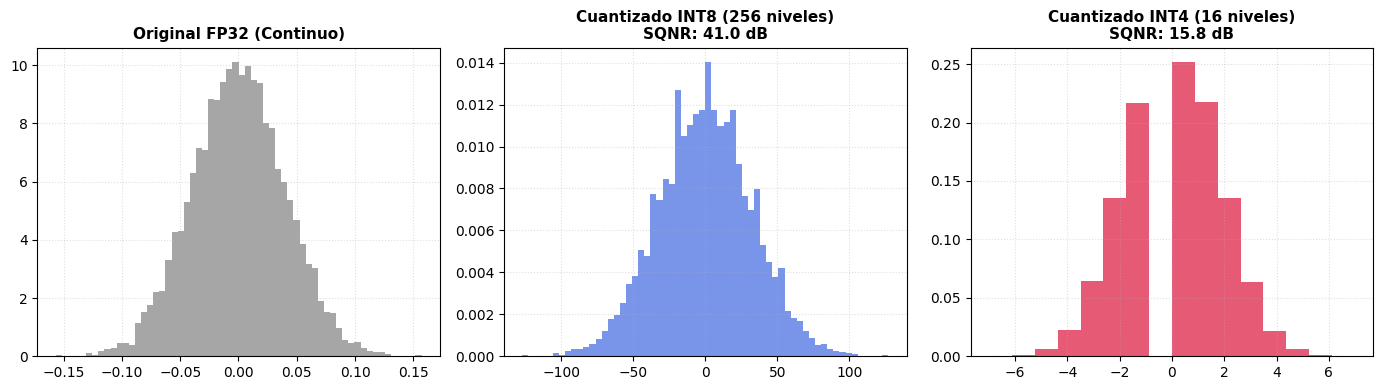

In [3]:
# Generar distribución típica de pesos de LLM: N(0, 0.04)
np.random.seed(42)
weights_fp32 = np.random.normal(0.0, 0.04, size=10000).astype(np.float32)

# 1. Cuantización INT8 (8 bits)
q8, scale8 = quantize_symmetric(weights_fp32, bits=8)
weights_rec8 = dequantize_symmetric(q8, scale8)

# 2. Cuantización INT4 (4 bits)
q4, scale4 = quantize_symmetric(weights_fp32, bits=4)
weights_rec4 = dequantize_symmetric(q4, scale4)

# Calcular SQNR (Signal-to-Quantization-Noise Ratio) en decibelios (dB)
def compute_sqnr(orig, rec):
    noise = orig - rec
    return 10.0 * np.log10(np.sum(orig ** 2) / np.sum(noise ** 2))

sqnr8 = compute_sqnr(weights_fp32, weights_rec8)
sqnr4 = compute_sqnr(weights_fp32, weights_rec4)

print(f"SQNR INT8: {sqnr8:.2f} dB (Fidelidad prácticamente indistinguible de FP32)")
print(f"SQNR INT4: {sqnr4:.2f} dB (Ruido perceptible por discretización en 16 niveles)")

# Visualizar histogramas de discretización
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(weights_fp32, bins=60, color='gray', alpha=0.7, density=True)
axes[0].set_title('Original FP32 (Continuo)', fontsize=11, fontweight='bold')
axes[0].grid(True, linestyle=':', alpha=0.4)

axes[1].hist(q8, bins=60, color='royalblue', alpha=0.7, density=True)
axes[1].set_title(f'Cuantizado INT8 (256 niveles)\nSQNR: {sqnr8:.1f} dB', fontsize=11, fontweight='bold')
axes[1].grid(True, linestyle=':', alpha=0.4)

axes[2].hist(q4, bins=16, color='crimson', alpha=0.7, density=True)
axes[2].set_title(f'Cuantizado INT4 (16 niveles)\nSQNR: {sqnr4:.1f} dB', fontsize=11, fontweight='bold')
axes[2].grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

### Simulación del Principio de AWQ (Activation-aware Weight Quantization)
Demostremos por qué los outliers de activación destruyen la precisión y cómo la estrategia de AWQ (proteger los canales destacados) rescata la calidad:

In [4]:
# Simulemos 64 canales de pesos y activaciones
np.random.seed(42)
n_channels = 64
W_matrix = np.random.normal(0, 0.05, size=(n_channels, n_channels)).astype(np.float32)
X_act = np.random.normal(0, 1.0, size=(100, n_channels)).astype(np.float32)

# Inyectar outliers emergentes en el canal 7 (magnitud 50x mayor, típico de LLMs)
X_act[:, 7] *= 50.0

# Salida real de referencia Y = X @ W.T
Y_ref = X_act @ W_matrix.T

# 1. Cuantización Naive a INT4 canal por canal
W_naive_q, scale_naive = quantize_symmetric(W_matrix, bits=4)
W_naive_rec = dequantize_symmetric(W_naive_q, scale_naive)
Y_naive = X_act @ W_naive_rec.T
err_naive = np.mean((Y_ref - Y_naive) ** 2)

# 2. Principio AWQ: Escalar los pesos del canal 7 para proteger su precisión relativa
# Multiplicamos el canal importante por un factor s_awq > 1 y dividimos la activacion por el mismo factor
s_awq = 4.0
W_awq = W_matrix.copy()
W_awq[:, 7] *= s_awq

# Cuantizar la matriz re-escalada
W_awq_q, scale_awq = quantize_symmetric(W_awq, bits=4)
W_awq_rec = dequantize_symmetric(W_awq_q, scale_awq)
# Deshacer el escalado en inferencia matematicamente exacto
W_awq_rec[:, 7] /= s_awq

Y_awq = X_act @ W_awq_rec.T
err_awq = np.mean((Y_ref - Y_awq) ** 2)

print(f"Error Cuadrático Medio Naive INT4: {err_naive:.6f}")
print(f"Error Cuadrático Medio AWQ   INT4: {err_awq:.6f}")
print(f"Reducción del error con AWQ:       {(1.0 - err_awq / err_naive) * 100:.1f}%")
assert err_awq < err_naive
print("\n🚀 ¡El principio de AWQ reduce drásticamente el error al amplificar la resolución de los canales críticos!")

Error Cuadrático Medio Naive INT4: 0.132828
Error Cuadrático Medio AWQ   INT4: 0.068194
Reducción del error con AWQ:       48.7%

🚀 ¡El principio de AWQ reduce drásticamente el error al amplificar la resolución de los canales críticos!


---

## 4. ⚡ Transición a PyTorch Moderno

En el ecosistema open source actual, existen dos grandes familias de cuantización:
1. **En GPUs (con CUDA / ROCm / DirectML):** `bitsandbytes` y `AutoAWQ`.
2. **En CPUs y hardware de consumo local:** `llama.cpp` y el formato **GGUF**.

### Tipos GGUF Populares:
* `Q8_0`: INT8 simétrico puro (pérdida de perplejidad $< 0.005$).
* `Q4_K_M`: Cuantización mixta de 4 bits con bloques pequeños de 32 pesos (*K-quants*), reteniendo el $99\%$ de las capacidades del modelo original con el $25\%$ de su tamaño en disco.

---

## 5. 🎯 Retos & Experimentos ("Tinker Time")

### Reto 1: Empaquetado de Nibbles (Bit Packing) de INT4 a UINT8
Como las arquitecturas de memoria direccionan bytes enteros (8 bits), almacenar enteros de 4 bits requiere empaquetar dos números de 4 bits (*nibbles*) en un solo byte `uint8` usando operaciones a nivel de bits (`bit shift` y `bit mask`):

In [5]:
# Empaquetar dos enteros en [0, 15] en un uint8
def pack_nibbles(val_low: int, val_high: int) -> int:
    return (val_low & 0x0F) | ((val_high & 0x0F) << 4)

def unpack_nibbles(byte_val: int) -> Tuple[int, int]:
    val_low = byte_val & 0x0F
    val_high = (byte_val >> 4) & 0x0F
    return val_low, val_high

# Ejemplo: Guardar 9 y 14 en un solo byte
byte_packed = pack_nibbles(9, 14)
v1, v2 = unpack_nibbles(byte_packed)

print(f"Valores originales: 9 y 14")
print(f"Byte empaquetado (Hex): 0x{byte_packed:02X} (Decimal: {byte_packed})")
print(f"Valores desempaquetados: {v1} y {v2}")
assert v1 == 9 and v2 == 14
print("✅ Empaquetado a nivel de bits verificado con éxito")

Valores originales: 9 y 14
Byte empaquetado (Hex): 0xE9 (Decimal: 233)
Valores desempaquetados: 9 y 14
✅ Empaquetado a nivel de bits verificado con éxito


### Reto 2 (Para resolver): Implementar Cuantización por Bloques (Group-wise Quantization)
En los formatos de vanguardia (GGUF `Q4_0` o AWQ), los pesos no se cuantizan con una sola escala global, sino en **bloques contiguos de 32 o 64 pesos** (`group_size`).

Implementa a continuación la función `quantize_groupwise_symmetric(weights, group_size=32, bits=4)`:

In [6]:
# TU CÓDIGO DEL RETO 2 AQUÍ
def quantize_groupwise_symmetric(
    weights: np.ndarray, 
    group_size: int = 32, 
    bits: int = 4
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Divide el tensor plano en bloques de tamano 'group_size' y cuantiza cada bloque independientemente.
    """
    # Tu implementación aquí
    pass

---

## 6. 📚 Referencias Fundamentales & Lecturas Recomendadas

### 📄 Papers Seminales
1. **Dettmers, T., et al. (2022):** *"LLM.int8(): 8-bit Matrix Multiplication for Transformers at Scale"*, NeurIPS 2022. [arXiv:2208.07339](https://arxiv.org/abs/2208.07339)
   * *¿Qué leer?* El descubrimiento de los outliers emergentes a escala 6.7B.
2. **Frantar, E., et al. (2022):** *"GPTQ: Accurate Post-Training Quantization for Generative Pre-trained Transformers"*, ICLR 2023. [arXiv:2210.17323](https://arxiv.org/abs/2210.17323)
   * *¿Qué leer?* Algoritmo de segundo orden con la inversa de la matriz Hessiana para compensar errores de cuantización.
3. **Lin, J., et al. (2023):** *"AWQ: Activation-aware Weight Quantization for On-Device LLM Compression and Acceleration"*, MLSys 2024. [arXiv:2306.00978](https://arxiv.org/abs/2306.00978)
   * *¿Qué leer?* La técnica de protección de canales de activación salientes que revolucionó la inferencia INT4.
4. **Jacob, B., et al. (2018):** *"Quantization and Training of Neural Networks for Efficient Integer-Arithmetic-Only Inference"*, CVPR 2018. [arXiv:1712.05877](https://arxiv.org/abs/1712.05877)
   * *¿Qué leer?* El clásico tutorial que formalizó la matemática de escala y punto cero ($s, z$).